# GammaNet contour-mask quadrant enrichment: baseline vs matched bias

Deze notebook doet expliciet twee aparte analyses op dezelfde afbeeldingen:

1. **Baseline / no bias**: gewone forward pass, zonder hook en zonder bias.
2. **Matched bias**: C-afbeeldingen krijgen bias op `C_CHANNELS`; straight-afbeeldingen krijgen bias op `STRAIGHT_CHANNELS`.

Voor beide condities wordt per afbeelding hetzelfde classificatieprincipe gebruikt:

`TL/TR/BL/BR kandidaatmaskers testen → contour enrichment per masker → hoogste enrichment = predicted quadrant`

Daarna worden baseline en bias naast elkaar gezet, zodat je direct kunt zien of de bias de classificatie verbetert.

In [1]:
# ============================================================
# 1. Imports, paths and settings
# ============================================================
import os, re, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torchvision import transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

PROJECT_ROOT = Path("/home/yentl/pytorch_gammanet")
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoint_epoch_40.pt"

IMAGE_DIR = PROJECT_ROOT / "Images_quad_final"
MASK_DIR = PROJECT_ROOT / "contour_masks_quad_final"

OUTPUT_DIR = PROJECT_ROOT / "outputs_contour_mask_quadrant_baseline_vs_bias_025"
CSV_DIR = OUTPUT_DIR / "csv"
PLOT_DIR = OUTPUT_DIR / "plots"
VIS_DIR = PLOT_DIR / "visual_checks"

for d in [OUTPUT_DIR, CSV_DIR, PLOT_DIR, VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

INPUT_SIZE = (320, 320)
ANALYSIS_LAYER = "h1_exc"
CONTOURS = ["C", "straight"]
QUADRANTS = ["TL", "TR", "BL", "BR"]

USE_ABS_ACTIVATION = True

# Dit is géén bias. Dit bepaalt alleen welke kanalen worden samengevat tot de activatiemap.
# matched_channels = bij C-afbeeldingen de C-kanalen uitlezen; bij straight-afbeeldingen de straight-kanalen uitlezen.
# all_channels = alle h1-kanalen middelen.
SCORE_CHANNEL_MODE = "matched_channels"

# Bias wordt alleen toegepast in de matched_bias analyse, nooit in baseline.
BIAS_STRENGTH = 0.25
BIAS_MODE = "add_mean_abs"  # opties: "add_mean_abs" of "multiply"

transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.ToTensor(),
])

print("IMAGE_DIR:", IMAGE_DIR)
print("MASK_DIR:", MASK_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("ANALYSIS_LAYER:", ANALYSIS_LAYER)
print("SCORE_CHANNEL_MODE:", SCORE_CHANNEL_MODE)
print("BIAS_STRENGTH:", BIAS_STRENGTH)


Using device: cpu
IMAGE_DIR: /home/yentl/pytorch_gammanet/Images_quad_final
MASK_DIR: /home/yentl/pytorch_gammanet/contour_masks_quad_final
OUTPUT_DIR: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025
ANALYSIS_LAYER: h1_exc
SCORE_CHANNEL_MODE: matched_channels
BIAS_STRENGTH: 0.25


In [2]:
# ============================================================
# 2. Model and general helper functions
# ============================================================
def load_model():
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))

    from gammanet.models.vgg16_gammanet_v2 import VGG16GammaNetV2

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

    if "config" in checkpoint and "model" in checkpoint["config"]:
        model_config = checkpoint["config"]["model"]
    elif "model_config" in checkpoint:
        model_config = checkpoint["model_config"]
    else:
        raise KeyError("Could not find model config in checkpoint.")

    model = VGG16GammaNetV2(model_config)

    state_dict = checkpoint.get("model_state_dict", checkpoint.get("state_dict", None))
    if state_dict is None:
        raise KeyError("Could not find model_state_dict or state_dict in checkpoint.")

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))

    model.to(DEVICE)
    model.eval()
    print("Model timesteps:", model.timesteps)
    return model


def normalize_contour_label(label):
    lower = str(label).strip().lower()
    if lower in ["c", "ccontour", "c_contour"]:
        return "C"
    if lower in ["straight", "line", "straightline", "straight_line"]:
        return "straight"
    return str(label)


def parse_image_filename(path):
    parts = path.stem.split("_")
    if len(parts) == 5:
        contour, quadrant, position, jitter, stim_id = parts
        contrast = "NA"
    elif len(parts) >= 6:
        contour, contrast, quadrant, position, jitter, stim_id = parts[:6]
    else:
        return None

    contour_type = normalize_contour_label(contour)
    quadrant = str(quadrant).upper()
    if contour_type not in CONTOURS or quadrant not in QUADRANTS:
        return None

    try:
        jitter_int = int(str(jitter).replace("J", ""))
    except Exception:
        jitter_int = np.nan
    try:
        position_int = int(position)
    except Exception:
        position_int = np.nan
    try:
        stim_id_int = int(stim_id)
    except Exception:
        stim_id_int = np.nan

    return {
        "filename": path.name,
        "path": str(path),
        "contour_type": contour_type,
        "contrast": contrast,
        "true_contour_quadrant": quadrant,
        "position": position_int,
        "jitter": jitter_int,
        "stimulus_id": stim_id_int,
    }


def candidate_mask_path(image_filename, candidate_quadrant):
    """Vervang alleen het quadrant-token in de bestandsnaam door TL/TR/BL/BR."""
    stem_parts = Path(image_filename).stem.split("_")
    suffix = Path(image_filename).suffix
    if len(stem_parts) == 5:
        q_idx = 1
    elif len(stem_parts) >= 6:
        q_idx = 2
    else:
        raise ValueError(f"Unexpected filename format: {image_filename}")
    new_parts = stem_parts.copy()
    new_parts[q_idx] = candidate_quadrant
    return MASK_DIR / ("_".join(new_parts) + suffix)


def load_image_tensor(path):
    pil_img = Image.open(path).convert("RGB")
    img_tensor = transform(pil_img).unsqueeze(0).to(DEVICE)
    return pil_img, img_tensor


def load_binary_mask(mask_path, target_shape):
    mask_img = Image.open(mask_path).convert("L")
    mask = np.asarray(mask_img).astype(np.float32) > 0
    if mask.shape != target_shape:
        mask_t = torch.tensor(mask.astype(np.float32))[None, None]
        resized = F.interpolate(mask_t, size=target_shape, mode="nearest")
        mask = resized[0, 0].numpy() > 0.5
    return mask


def reset_and_forward(model, img_tensor):
    model.reset_hidden_states()
    with torch.no_grad():
        _ = model(img_tensor)


def get_state(model, layer_name):
    state = getattr(model, layer_name, None)
    if state is None:
        raise ValueError(f"{layer_name} is None. Run model first or check layer name.")
    return state


def normalize_for_plot(x, eps=1e-8):
    x = np.asarray(x)
    x = x - np.nanmin(x)
    return x / (np.nanmax(x) + eps)


In [3]:
# ============================================================
# 3. Load C/straight channel classification
# ============================================================
CLASSIFICATION_DIR = (
    PROJECT_ROOT
    / "outputs_bias_contour_final"
    / "plots"
    / "05_channel_classification"
    / "channel_classification"
)

C_CHANNELS_CSV = CLASSIFICATION_DIR / "C_channels_h1.csv"
STRAIGHT_CHANNELS_CSV = CLASSIFICATION_DIR / "straight_channels_h1.csv"


def load_channel_list(csv_path):
    df = pd.read_csv(csv_path)
    if "channel" in df.columns:
        return df["channel"].astype(int).tolist()
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) == 0:
        raise ValueError(f"No numeric channel column found in {csv_path}")
    return df[numeric_cols[0]].astype(int).tolist()


if not C_CHANNELS_CSV.exists() or not STRAIGHT_CHANNELS_CSV.exists():
    raise FileNotFoundError(
        "Channel classification files not found.\n"
        f"Expected C channels here: {C_CHANNELS_CSV}\n"
        f"Expected straight channels here: {STRAIGHT_CHANNELS_CSV}\n\n"
        "Run the channel-classification notebook first, or check CLASSIFICATION_DIR."
    )

C_CHANNELS = load_channel_list(C_CHANNELS_CSV)
STRAIGHT_CHANNELS = load_channel_list(STRAIGHT_CHANNELS_CSV)

print(f"Loaded {len(C_CHANNELS)} C channels from: {C_CHANNELS_CSV}")
print(f"Loaded {len(STRAIGHT_CHANNELS)} straight channels from: {STRAIGHT_CHANNELS_CSV}")
print("Important: loading these channels does NOT apply bias. Bias is only applied inside the matched_bias hook.")


Loaded 61 C channels from: /home/yentl/pytorch_gammanet/outputs_bias_contour_final/plots/05_channel_classification/channel_classification/C_channels_h1.csv
Loaded 67 straight channels from: /home/yentl/pytorch_gammanet/outputs_bias_contour_final/plots/05_channel_classification/channel_classification/straight_channels_h1.csv
Important: loading these channels does NOT apply bias. Bias is only applied inside the matched_bias hook.


In [4]:
# ============================================================
# 4. Activation maps, enrichment and bias hook
# ============================================================
def selected_channels_for_contour(contour_type):
    contour_type = normalize_contour_label(contour_type)
    if contour_type == "C":
        return C_CHANNELS
    if contour_type == "straight":
        return STRAIGHT_CHANNELS
    raise ValueError(f"Unknown contour_type: {contour_type}")


def channel_map(state, contour_type, use_abs=True, channel_mode="matched_channels"):
    x = state.detach()
    if use_abs:
        x = x.abs()
    if channel_mode == "all_channels":
        return x.mean(dim=1)[0].cpu().numpy()
    if channel_mode == "matched_channels":
        channels = selected_channels_for_contour(contour_type)
        idx = torch.tensor(channels, device=x.device, dtype=torch.long)
        return x[:, idx, :, :].mean(dim=1)[0].cpu().numpy()
    raise ValueError(f"Unknown channel_mode: {channel_mode}")


def resize_map_to_image(fmap, pil_img):
    fmap_t = torch.tensor(fmap, dtype=torch.float32)[None, None]
    resized = F.interpolate(
        fmap_t,
        size=pil_img.size[::-1],
        mode="bilinear",
        align_corners=False,
    )
    return resized[0, 0].numpy()


def contour_enrichment(fmap, mask, eps=1e-8):
    mask = mask.astype(bool)
    if mask.sum() == 0:
        return {
            "activation_inside_mask": np.nan,
            "activation_outside_mask": np.nan,
            "contour_enrichment": np.nan,
            "mask_area_pixels": 0,
            "mask_area_fraction": 0.0,
        }
    mean_inside = float(np.nanmean(fmap[mask]))
    mean_outside = float(np.nanmean(fmap[~mask]))
    return {
        "activation_inside_mask": mean_inside,
        "activation_outside_mask": mean_outside,
        "contour_enrichment": float(mean_inside / (mean_outside + eps)),
        "mask_area_pixels": int(mask.sum()),
        "mask_area_fraction": float(mask.mean()),
    }


class TDH1Bias:
    """Tijdelijke forward hook. Wordt alleen gebruikt binnen `with TDH1Bias(...)`.
    Zodra de `with` block klaar is, wordt de hook verwijderd.
    Daardoor kan baseline nooit per ongeluk bias krijgen.
    """
    def __init__(self, model, channels, strength=0.25, mode="add_mean_abs"):
        self.model = model
        self.channels = [int(c) for c in channels]
        self.strength = float(strength)
        self.mode = mode
        self.handle = None

    def _hook(self, module, inputs, output):
        if not isinstance(output, tuple):
            return output
        exc = output[0]
        if exc is None or len(self.channels) == 0:
            return output
        exc = exc.clone()
        idx = torch.tensor(self.channels, device=exc.device, dtype=torch.long)
        if self.mode == "add_mean_abs":
            scale = exc.detach().abs().mean(dim=(2, 3), keepdim=True) + 1e-8
            exc[:, idx, :, :] = exc[:, idx, :, :] + self.strength * scale[:, idx, :, :]
        elif self.mode == "multiply":
            exc[:, idx, :, :] = exc[:, idx, :, :] * (1.0 + self.strength)
        else:
            raise ValueError(f"Unknown bias mode: {self.mode}")
        return (exc,) + output[1:]

    def __enter__(self):
        self.handle = self.model.td_fgru_1.register_forward_hook(self._hook)
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        if self.handle is not None:
            self.handle.remove()
        return False


In [5]:
# ============================================================
# 5. Load model and image table; check candidate masks
# ============================================================
model = load_model()

rows = []
for path in sorted(IMAGE_DIR.glob("*.png")):
    info = parse_image_filename(path)
    if info is not None:
        rows.append(info)

image_df = pd.DataFrame(rows)
if image_df.empty:
    raise RuntimeError(f"No valid C/straight images found in {IMAGE_DIR}.")

image_df = image_df.sort_values(["contour_type", "true_contour_quadrant", "filename"]).reset_index(drop=True)

missing_masks = []
for _, row in image_df.iterrows():
    for q in QUADRANTS:
        mp = candidate_mask_path(row["filename"], q)
        if not mp.exists():
            missing_masks.append({
                "filename": row["filename"],
                "candidate_quadrant": q,
                "expected_mask": str(mp),
            })

missing_masks_df = pd.DataFrame(missing_masks)

print("Number of images:", len(image_df))
print(image_df.groupby(["contour_type", "true_contour_quadrant"]).size())
print("Missing candidate masks:", len(missing_masks_df))

if not missing_masks_df.empty:
    display(missing_masks_df.head(20))
    raise FileNotFoundError("Some candidate masks are missing. See missing_masks_df above.")

display(image_df.head())


/tmp/ipykernel_92128/3728779099.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
/home/yentl/anaconda3/envs

Missing keys: 0
Unexpected keys: 18
Model timesteps: 4
Number of images: 48
contour_type  true_contour_quadrant
C             BL                       6
              BR                       6
              TL                       6
              TR                       6
straight      BL                       6
              BR                       6
              TL                       6
              TR                       6
dtype: int64
Missing candidate masks: 0


,filename,path,contour_type,contrast,true_contour_quadrant,position,jitter,stimulus_id
0,C_BL_0_J000_000.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,NA,BL,0,0,0
1,C_BL_0_J000_001.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,NA,BL,0,0,1
2,C_BL_0_J000_002.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,NA,BL,0,0,2
3,C_BL_0_J000_003.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,NA,BL,0,0,3
4,C_BL_0_J000_004.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,NA,BL,0,0,4


In [6]:
# ============================================================
# 6. Core function: one complete analysis pass
# ============================================================
def forward_baseline(model, img_tensor):
    """Geen bias, geen hook: gewone model-forward."""
    reset_and_forward(model, img_tensor)


def forward_matched_bias(model, img_tensor, contour_type):
    """Matched bias: C -> C channels, straight -> straight channels."""
    channels = selected_channels_for_contour(contour_type)
    with TDH1Bias(model, channels, strength=BIAS_STRENGTH, mode=BIAS_MODE):
        reset_and_forward(model, img_tensor)


def analyze_one_condition(condition_name, use_bias):
    records = []
    activation_examples = {}
    print(f"\n=== Running {condition_name} | use_bias={use_bias} ===")

    for _, row in tqdm(image_df.iterrows(), total=len(image_df), desc=condition_name):
        pil_img, img_tensor = load_image_tensor(row["path"])

        if use_bias:
            forward_matched_bias(model, img_tensor, row["contour_type"])
            applied_bias_channels = selected_channels_for_contour(row["contour_type"])
            applied_bias_strength = BIAS_STRENGTH
        else:
            forward_baseline(model, img_tensor)
            applied_bias_channels = []
            applied_bias_strength = 0.0

        state = get_state(model, ANALYSIS_LAYER)
        fmap = channel_map(
            state,
            contour_type=row["contour_type"],
            use_abs=USE_ABS_ACTIVATION,
            channel_mode=SCORE_CHANNEL_MODE,
        )
        fmap_resized = resize_map_to_image(fmap, pil_img)

        if len(activation_examples) < 8:
            activation_examples[row["filename"]] = fmap_resized

        record = {
            "condition": condition_name,
            "use_bias": bool(use_bias),
            "bias_strength": applied_bias_strength,
            "bias_mode": BIAS_MODE if use_bias else "none",
            "n_bias_channels": len(applied_bias_channels),
            "filename": row["filename"],
            "path": row["path"],
            "contour_type": row["contour_type"],
            "true_contour_quadrant": row["true_contour_quadrant"],
            "contrast": row["contrast"],
            "position": row["position"],
            "jitter": row["jitter"],
            "stimulus_id": row["stimulus_id"],
            "analysis_layer": ANALYSIS_LAYER,
            "score_channel_mode": SCORE_CHANNEL_MODE,
            "use_abs_activation": USE_ABS_ACTIVATION,
        }

        enrichments = {}
        for q in QUADRANTS:
            mask_path = candidate_mask_path(row["filename"], q)
            mask = load_binary_mask(mask_path, target_shape=fmap_resized.shape)
            scores = contour_enrichment(fmap_resized, mask)
            enrichments[q] = scores["contour_enrichment"]
            record[f"mask_{q}_path"] = str(mask_path)
            record[f"enrichment_{q}"] = scores["contour_enrichment"]
            record[f"inside_activation_{q}"] = scores["activation_inside_mask"]
            record[f"outside_activation_{q}"] = scores["activation_outside_mask"]
            record[f"mask_area_fraction_{q}"] = scores["mask_area_fraction"]

        predicted_q = max(enrichments, key=enrichments.get)
        record["predicted_quadrant"] = predicted_q
        record["highest_contour_enrichment"] = enrichments[predicted_q]
        record["true_quadrant_enrichment"] = enrichments[row["true_contour_quadrant"]]
        record["matches_true_quadrant"] = predicted_q == row["true_contour_quadrant"]
        records.append(record)

    return pd.DataFrame(records), activation_examples


In [7]:
# ============================================================
# 7. Run analysis 1: BASELINE / NO BIAS
# ============================================================
baseline_df, baseline_examples = analyze_one_condition(
    condition_name="baseline",
    use_bias=False,
)

baseline_path = CSV_DIR / "baseline_no_bias_contour_mask_enrichment_results.csv"
baseline_df.to_csv(baseline_path, index=False)
print("Saved:", baseline_path)

display(baseline_df.head())
print("Baseline mean accuracy:", baseline_df["matches_true_quadrant"].mean())



=== Running baseline | use_bias=False ===


baseline: 100%|██████████| 48/48 [05:28<00:00,  6.85s/it]

Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/baseline_no_bias_contour_mask_enrichment_results.csv


,condition,use_bias,bias_strength,bias_mode,n_bias_channels,filename,path,contour_type,true_contour_quadrant,contrast,...,mask_area_fraction_BL,mask_BR_path,enrichment_BR,inside_activation_BR,outside_activation_BR,mask_area_fraction_BR,predicted_quadrant,highest_contour_enrichment,true_quadrant_enrichment,matches_true_quadrant
0,baseline,False,0.0,none,0,C_BL_0_J000_000.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.931072,2.119202,2.276088,0.016617,BL,1.894901,1.894901,True
1,baseline,False,0.0,none,0,C_BL_0_J000_001.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.929569,2.114527,2.274738,0.016617,BL,1.972563,1.972563,True
2,baseline,False,0.0,none,0,C_BL_0_J000_002.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.872679,1.989261,2.279488,0.016617,BL,1.826229,1.826229,True
3,baseline,False,0.0,none,0,C_BL_0_J000_003.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.919328,2.094756,2.278573,0.016617,BL,1.763472,1.763472,True
4,baseline,False,0.0,none,0,C_BL_0_J000_004.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.928057,2.110819,2.274449,0.016617,BL,1.778613,1.778613,True


Baseline mean accuracy: 1.0


In [8]:
# ============================================================
# 8. Run analysis 2: MATCHED BIAS
# ============================================================
bias_df, bias_examples = analyze_one_condition(
    condition_name="matched_bias",
    use_bias=True,
)

bias_path = CSV_DIR / "matched_bias_025_contour_mask_enrichment_results.csv"
bias_df.to_csv(bias_path, index=False)
print("Saved:", bias_path)

display(bias_df.head())
print("Matched-bias mean accuracy:", bias_df["matches_true_quadrant"].mean())



=== Running matched_bias | use_bias=True ===


matched_bias: 100%|██████████| 48/48 [05:24<00:00,  6.76s/it]

Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/matched_bias_025_contour_mask_enrichment_results.csv


,condition,use_bias,bias_strength,bias_mode,n_bias_channels,filename,path,contour_type,true_contour_quadrant,contrast,...,mask_area_fraction_BL,mask_BR_path,enrichment_BR,inside_activation_BR,outside_activation_BR,mask_area_fraction_BR,predicted_quadrant,highest_contour_enrichment,true_quadrant_enrichment,matches_true_quadrant
0,matched_bias,True,0.25,add_mean_abs,61,C_BL_0_J000_000.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.935961,2.797023,2.988396,0.016617,BL,1.771279,1.771279,True
1,matched_bias,True,0.25,add_mean_abs,61,C_BL_0_J000_001.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.932880,2.784249,2.984572,0.016617,BL,1.836431,1.836431,True
2,matched_bias,True,0.25,add_mean_abs,61,C_BL_0_J000_002.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.894822,2.677996,2.992770,0.016617,BL,1.721191,1.721191,True
3,matched_bias,True,0.25,add_mean_abs,61,C_BL_0_J000_003.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.926364,2.770106,2.990299,0.016617,BL,1.650281,1.650281,True
4,matched_bias,True,0.25,add_mean_abs,61,C_BL_0_J000_004.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.930646,2.780468,2.987676,0.016617,BL,1.667255,1.667255,True


Matched-bias mean accuracy: 1.0


In [9]:
# ============================================================
# 9. Combine baseline and bias results
# ============================================================
results_df = pd.concat([baseline_df, bias_df], ignore_index=True)
combined_path = CSV_DIR / "combined_baseline_vs_matched_bias_results.csv"
results_df.to_csv(combined_path, index=False)
print("Saved:", combined_path)

display(results_df.head())


Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/combined_baseline_vs_matched_bias_results.csv


,condition,use_bias,bias_strength,bias_mode,n_bias_channels,filename,path,contour_type,true_contour_quadrant,contrast,...,mask_area_fraction_BL,mask_BR_path,enrichment_BR,inside_activation_BR,outside_activation_BR,mask_area_fraction_BR,predicted_quadrant,highest_contour_enrichment,true_quadrant_enrichment,matches_true_quadrant
0,baseline,False,0.0,none,0,C_BL_0_J000_000.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.931072,2.119202,2.276088,0.016617,BL,1.894901,1.894901,True
1,baseline,False,0.0,none,0,C_BL_0_J000_001.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.929569,2.114527,2.274738,0.016617,BL,1.972563,1.972563,True
2,baseline,False,0.0,none,0,C_BL_0_J000_002.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.872679,1.989261,2.279488,0.016617,BL,1.826229,1.826229,True
3,baseline,False,0.0,none,0,C_BL_0_J000_003.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.919328,2.094756,2.278573,0.016617,BL,1.763472,1.763472,True
4,baseline,False,0.0,none,0,C_BL_0_J000_004.png,/home/yentl/pytorch_gammanet/Images_quad_final...,C,BL,NA,...,0.016472,/home/yentl/pytorch_gammanet/contour_masks_qua...,0.928057,2.110819,2.274449,0.016617,BL,1.778613,1.778613,True


In [10]:
# ============================================================
# 10. Summary tables
# ============================================================
summary_df = (
    results_df
    .groupby(["condition", "use_bias", "contour_type", "true_contour_quadrant", "score_channel_mode"])
    .agg(
        n_images=("filename", "count"),
        n_correct=("matches_true_quadrant", "sum"),
        proportion_correct=("matches_true_quadrant", "mean"),
        mean_highest_enrichment=("highest_contour_enrichment", "mean"),
        mean_true_quadrant_enrichment=("true_quadrant_enrichment", "mean"),
        mean_enrichment_TL=("enrichment_TL", "mean"),
        mean_enrichment_TR=("enrichment_TR", "mean"),
        mean_enrichment_BL=("enrichment_BL", "mean"),
        mean_enrichment_BR=("enrichment_BR", "mean"),
    )
    .reset_index()
)
summary_path = CSV_DIR / "summary_by_condition_contour_quadrant.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved:", summary_path)
display(summary_df)

overall_summary_df = (
    results_df
    .groupby(["condition", "use_bias", "contour_type", "score_channel_mode"])
    .agg(
        n_images=("filename", "count"),
        n_correct=("matches_true_quadrant", "sum"),
        proportion_correct=("matches_true_quadrant", "mean"),
        mean_highest_enrichment=("highest_contour_enrichment", "mean"),
        mean_true_quadrant_enrichment=("true_quadrant_enrichment", "mean"),
    )
    .reset_index()
)
overall_summary_path = CSV_DIR / "overall_summary_baseline_vs_bias.csv"
overall_summary_df.to_csv(overall_summary_path, index=False)
print("Saved:", overall_summary_path)
display(overall_summary_df)


Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/summary_by_condition_contour_quadrant.csv


,condition,use_bias,contour_type,true_contour_quadrant,score_channel_mode,n_images,n_correct,proportion_correct,mean_highest_enrichment,mean_true_quadrant_enrichment,mean_enrichment_TL,mean_enrichment_TR,mean_enrichment_BL,mean_enrichment_BR
0,baseline,False,C,BL,matched_channels,6,6,1.0,1.850323,1.850323,0.960496,0.895496,1.850323,0.915908
1,baseline,False,C,BR,matched_channels,6,6,1.0,1.777635,1.777635,1.042382,0.857586,1.073989,1.777635
2,baseline,False,C,TL,matched_channels,6,6,1.0,1.786312,1.786312,1.786312,0.891569,1.020014,0.913361
3,baseline,False,C,TR,matched_channels,6,6,1.0,1.541632,1.541632,1.011104,1.541632,1.124637,0.902982
4,baseline,False,straight,BL,matched_channels,6,6,1.0,1.817655,1.817655,1.025638,0.920787,1.817655,0.920266
5,baseline,False,straight,BR,matched_channels,6,6,1.0,1.812149,1.812149,0.975292,0.932210,1.056249,1.812149
6,baseline,False,straight,TL,matched_channels,6,6,1.0,1.609458,1.609458,1.609458,0.927657,1.039029,0.952495
7,baseline,False,straight,TR,matched_channels,6,6,1.0,1.812424,1.812424,1.015483,1.812424,0.979755,0.942502
8,matched_bias,True,C,BL,matched_channels,6,6,1.0,1.730959,1.730959,0.962020,0.913640,1.730959,0.925816
9,matched_bias,True,C,BR,matched_channels,6,6,1.0,1.669530,1.669530,1.034020,0.878686,1.054413,1.669530


Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/overall_summary_baseline_vs_bias.csv


,condition,use_bias,contour_type,score_channel_mode,n_images,n_correct,proportion_correct,mean_highest_enrichment,mean_true_quadrant_enrichment
0,baseline,False,C,matched_channels,24,24,1.0,1.738975,1.738975
1,baseline,False,straight,matched_channels,24,24,1.0,1.762922,1.762922
2,matched_bias,True,C,matched_channels,24,24,1.0,1.629915,1.629915
3,matched_bias,True,straight,matched_channels,24,24,1.0,1.643142,1.643142


In [11]:
# ============================================================
# 11. Paired baseline-vs-bias comparison per image
# ============================================================
key_cols = ["filename", "contour_type", "true_contour_quadrant", "jitter", "stimulus_id"]

base_small = baseline_df[key_cols + [
    "predicted_quadrant", "matches_true_quadrant", "highest_contour_enrichment", "true_quadrant_enrichment",
    "enrichment_TL", "enrichment_TR", "enrichment_BL", "enrichment_BR",
]].copy().rename(columns={
    "predicted_quadrant": "baseline_predicted_quadrant",
    "matches_true_quadrant": "baseline_correct",
    "highest_contour_enrichment": "baseline_highest_enrichment",
    "true_quadrant_enrichment": "baseline_true_quadrant_enrichment",
    "enrichment_TL": "baseline_enrichment_TL",
    "enrichment_TR": "baseline_enrichment_TR",
    "enrichment_BL": "baseline_enrichment_BL",
    "enrichment_BR": "baseline_enrichment_BR",
})

bias_small = bias_df[key_cols + [
    "predicted_quadrant", "matches_true_quadrant", "highest_contour_enrichment", "true_quadrant_enrichment",
    "enrichment_TL", "enrichment_TR", "enrichment_BL", "enrichment_BR",
]].copy().rename(columns={
    "predicted_quadrant": "bias_predicted_quadrant",
    "matches_true_quadrant": "bias_correct",
    "highest_contour_enrichment": "bias_highest_enrichment",
    "true_quadrant_enrichment": "bias_true_quadrant_enrichment",
    "enrichment_TL": "bias_enrichment_TL",
    "enrichment_TR": "bias_enrichment_TR",
    "enrichment_BL": "bias_enrichment_BL",
    "enrichment_BR": "bias_enrichment_BR",
})

comparison_df = base_small.merge(bias_small, on=key_cols, how="inner")
comparison_df["correctness_change"] = np.select(
    [
        (~comparison_df["baseline_correct"]) & (comparison_df["bias_correct"]),
        (comparison_df["baseline_correct"]) & (~comparison_df["bias_correct"]),
        (comparison_df["baseline_correct"]) & (comparison_df["bias_correct"]),
        (~comparison_df["baseline_correct"]) & (~comparison_df["bias_correct"]),
    ],
    ["improved", "worse", "same_correct", "same_wrong"],
    default="unknown",
)
comparison_df["delta_highest_enrichment_bias_minus_baseline"] = comparison_df["bias_highest_enrichment"] - comparison_df["baseline_highest_enrichment"]
comparison_df["delta_true_quadrant_enrichment_bias_minus_baseline"] = comparison_df["bias_true_quadrant_enrichment"] - comparison_df["baseline_true_quadrant_enrichment"]

comparison_path = CSV_DIR / "paired_image_level_baseline_vs_bias_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

display(comparison_df.head())
display(comparison_df["correctness_change"].value_counts())


Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/paired_image_level_baseline_vs_bias_comparison.csv


,filename,contour_type,true_contour_quadrant,jitter,stimulus_id,baseline_predicted_quadrant,baseline_correct,baseline_highest_enrichment,baseline_true_quadrant_enrichment,baseline_enrichment_TL,...,bias_correct,bias_highest_enrichment,bias_true_quadrant_enrichment,bias_enrichment_TL,bias_enrichment_TR,bias_enrichment_BL,bias_enrichment_BR,correctness_change,delta_highest_enrichment_bias_minus_baseline,delta_true_quadrant_enrichment_bias_minus_baseline
0,C_BL_0_J000_000.png,C,BL,0,0,BL,True,1.894901,1.894901,1.032888,...,True,1.771279,1.771279,1.024841,0.900664,1.771279,0.935961,same_correct,-0.123622,-0.123622
1,C_BL_0_J000_001.png,C,BL,0,1,BL,True,1.972563,1.972563,0.960312,...,True,1.836431,1.836431,0.964173,0.948530,1.836431,0.932880,same_correct,-0.136132,-0.136132
2,C_BL_0_J000_002.png,C,BL,0,2,BL,True,1.826229,1.826229,0.976352,...,True,1.721191,1.721191,0.969758,0.904474,1.721191,0.894822,same_correct,-0.105037,-0.105037
3,C_BL_0_J000_003.png,C,BL,0,3,BL,True,1.763472,1.763472,0.942590,...,True,1.650281,1.650281,0.947668,0.935528,1.650281,0.926364,same_correct,-0.113192,-0.113192
4,C_BL_0_J000_004.png,C,BL,0,4,BL,True,1.778613,1.778613,0.894882,...,True,1.667255,1.667255,0.909167,0.909446,1.667255,0.930646,same_correct,-0.111358,-0.111358


correctness_change
same_correct    48
Name: count, dtype: int64

In [12]:
# ============================================================
# 12. Confusion matrices
# ============================================================
for condition in ["baseline", "matched_bias"]:
    for contour in CONTOURS:
        subset = results_df[(results_df["condition"] == condition) & (results_df["contour_type"] == contour)]
        if subset.empty:
            continue
        conf = pd.crosstab(
            subset["true_contour_quadrant"],
            subset["predicted_quadrant"],
            rownames=["true"],
            colnames=["predicted"],
            dropna=False,
        ).reindex(index=QUADRANTS, columns=QUADRANTS, fill_value=0)
        save_path = CSV_DIR / f"confusion_{condition}_{contour}.csv"
        conf.to_csv(save_path)
        print(f"\n{condition} - {contour}")
        display(conf)
        print("Saved:", save_path)



baseline - C


predicted,TL,TR,BL,BR
true,,,,
TL,6,0,0,0
TR,0,6,0,0
BL,0,0,6,0
BR,0,0,0,6


Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/confusion_baseline_C.csv

baseline - straight


predicted,TL,TR,BL,BR
true,,,,
TL,6,0,0,0
TR,0,6,0,0
BL,0,0,6,0
BR,0,0,0,6


Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/confusion_baseline_straight.csv

matched_bias - C


predicted,TL,TR,BL,BR
true,,,,
TL,6,0,0,0
TR,0,6,0,0
BL,0,0,6,0
BR,0,0,0,6


Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/confusion_matched_bias_C.csv

matched_bias - straight


predicted,TL,TR,BL,BR
true,,,,
TL,6,0,0,0
TR,0,6,0,0
BL,0,0,6,0
BR,0,0,0,6


Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/confusion_matched_bias_straight.csv


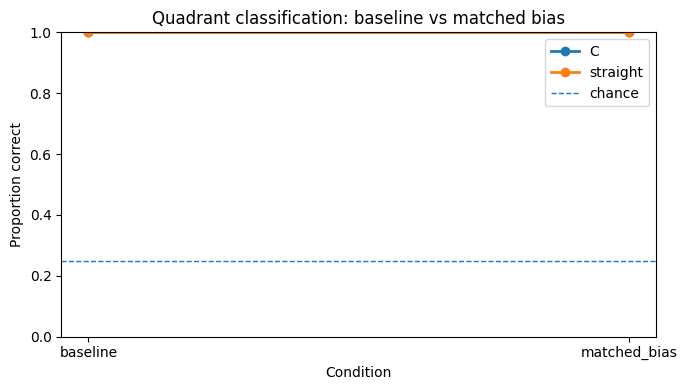

Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/plots/accuracy_baseline_vs_matched_bias.png


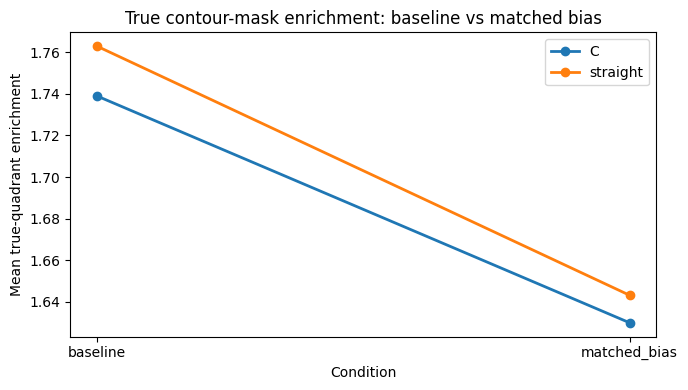

Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/plots/true_quadrant_enrichment_baseline_vs_matched_bias.png


In [13]:
# ============================================================
# 13. Plots: baseline vs bias accuracy and enrichment
# ============================================================
plot_df = overall_summary_df.copy()
condition_order = ["baseline", "matched_bias"]

plt.figure(figsize=(7, 4))
for contour in CONTOURS:
    subset = plot_df[plot_df["contour_type"] == contour].set_index("condition").reindex(condition_order).reset_index()
    if subset["proportion_correct"].isna().all():
        continue
    plt.plot(subset["condition"], subset["proportion_correct"], marker="o", linewidth=2, label=contour)
plt.axhline(0.25, linestyle="--", linewidth=1, label="chance")
plt.ylim(0, 1)
plt.xlabel("Condition")
plt.ylabel("Proportion correct")
plt.title("Quadrant classification: baseline vs matched bias")
plt.legend()
plt.tight_layout()
plot_path = PLOT_DIR / "accuracy_baseline_vs_matched_bias.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)

plt.figure(figsize=(7, 4))
for contour in CONTOURS:
    subset = plot_df[plot_df["contour_type"] == contour].set_index("condition").reindex(condition_order).reset_index()
    if subset["mean_true_quadrant_enrichment"].isna().all():
        continue
    plt.plot(subset["condition"], subset["mean_true_quadrant_enrichment"], marker="o", linewidth=2, label=contour)
plt.xlabel("Condition")
plt.ylabel("Mean true-quadrant enrichment")
plt.title("True contour-mask enrichment: baseline vs matched bias")
plt.legend()
plt.tight_layout()
plot_path = PLOT_DIR / "true_quadrant_enrichment_baseline_vs_matched_bias.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)


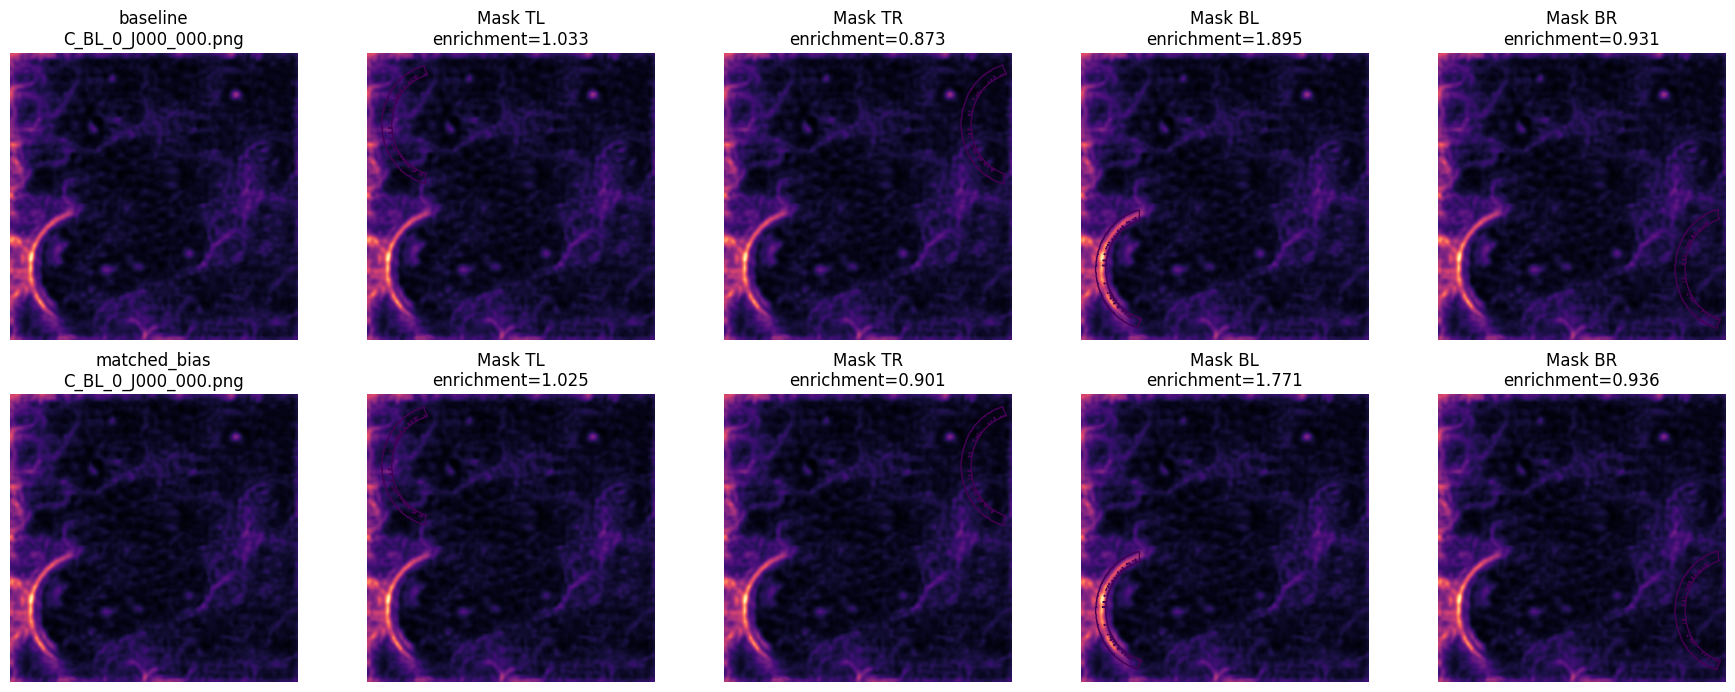

Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/plots/visual_checks/baseline_vs_bias_visual_check_C_BL_0_J000_000.png


In [14]:
# ============================================================
# 14. Optional: visual check baseline vs bias for one image
# ============================================================
def compute_activation_map_for_visual(row, use_bias):
    pil_img, img_tensor = load_image_tensor(row["path"])
    if use_bias:
        forward_matched_bias(model, img_tensor, row["contour_type"])
    else:
        forward_baseline(model, img_tensor)
    state = get_state(model, ANALYSIS_LAYER)
    fmap = channel_map(
        state,
        contour_type=row["contour_type"],
        use_abs=USE_ABS_ACTIVATION,
        channel_mode=SCORE_CHANNEL_MODE,
    )
    return pil_img, resize_map_to_image(fmap, pil_img)

example_index = 0
example = image_df.iloc[example_index]

pil_img, fmap_baseline = compute_activation_map_for_visual(example, use_bias=False)
_, fmap_bias = compute_activation_map_for_visual(example, use_bias=True)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for row_idx, (condition_label, fmap) in enumerate([
    ("baseline", fmap_baseline),
    ("matched_bias", fmap_bias),
]):
    axes[row_idx, 0].imshow(normalize_for_plot(fmap), cmap="magma")
    axes[row_idx, 0].set_title(f"{condition_label}\n{example['filename']}")
    axes[row_idx, 0].axis("off")
    for ax, q in zip(axes[row_idx, 1:], QUADRANTS):
        mask_path = candidate_mask_path(example["filename"], q)
        mask = load_binary_mask(mask_path, target_shape=fmap.shape)
        score = contour_enrichment(fmap, mask)["contour_enrichment"]
        ax.imshow(normalize_for_plot(fmap), cmap="magma")
        ax.contour(mask.astype(float), levels=[0.5], linewidths=1)
        ax.set_title(f"Mask {q}\nenrichment={score:.3f}")
        ax.axis("off")

plt.tight_layout()
visual_path = VIS_DIR / f"baseline_vs_bias_visual_check_{example['filename'].replace('.png', '')}.png"
plt.savefig(visual_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", visual_path)


## Belangrijkste output

Na het runnen staan de belangrijkste bestanden hier:

- `outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/baseline_no_bias_contour_mask_enrichment_results.csv`  
  Alleen de baseline/no-bias analyse.

- `outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/matched_bias_025_contour_mask_enrichment_results.csv`  
  Alleen de matched-bias analyse.

- `outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/combined_baseline_vs_matched_bias_results.csv`  
  Beide condities onder elkaar.

- `outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/paired_image_level_baseline_vs_bias_comparison.csv`  
  Per afbeelding baseline en bias naast elkaar, inclusief `correctness_change`.

- `outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/overall_summary_baseline_vs_bias.csv`  
  Samenvatting van accuracy en enrichment per conditie en contourtype.

Belangrijk: in `baseline` is `use_bias=False`, `bias_strength=0.0`, `bias_mode='none'`, en wordt er geen hook geregistreerd.

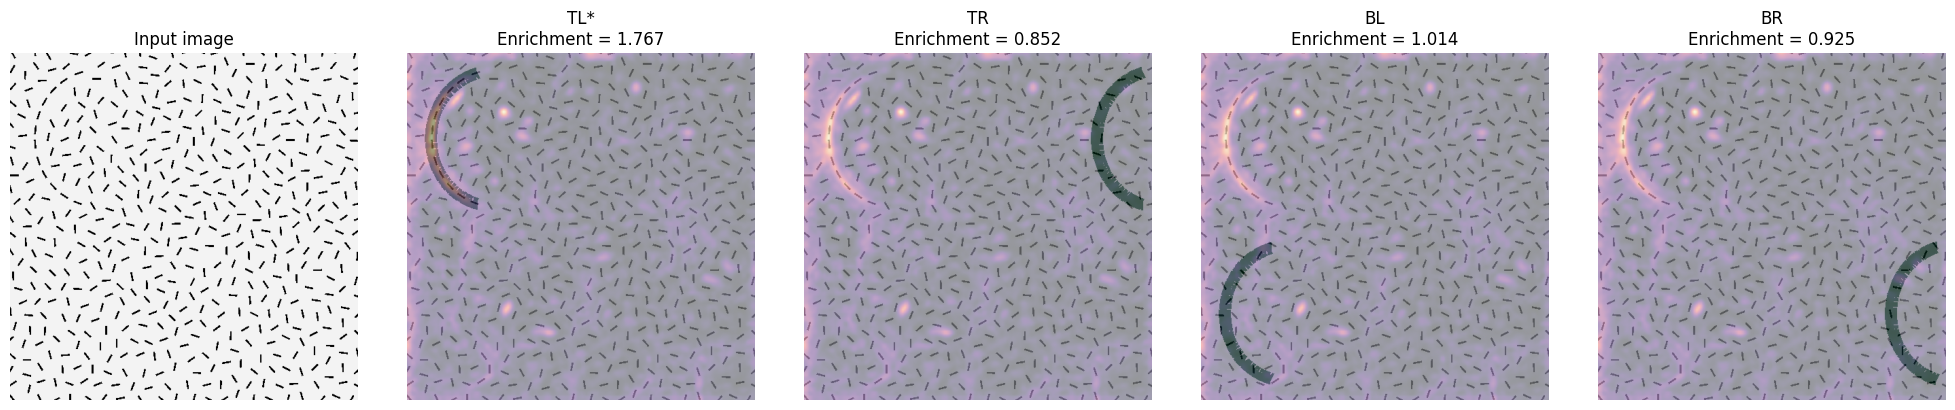

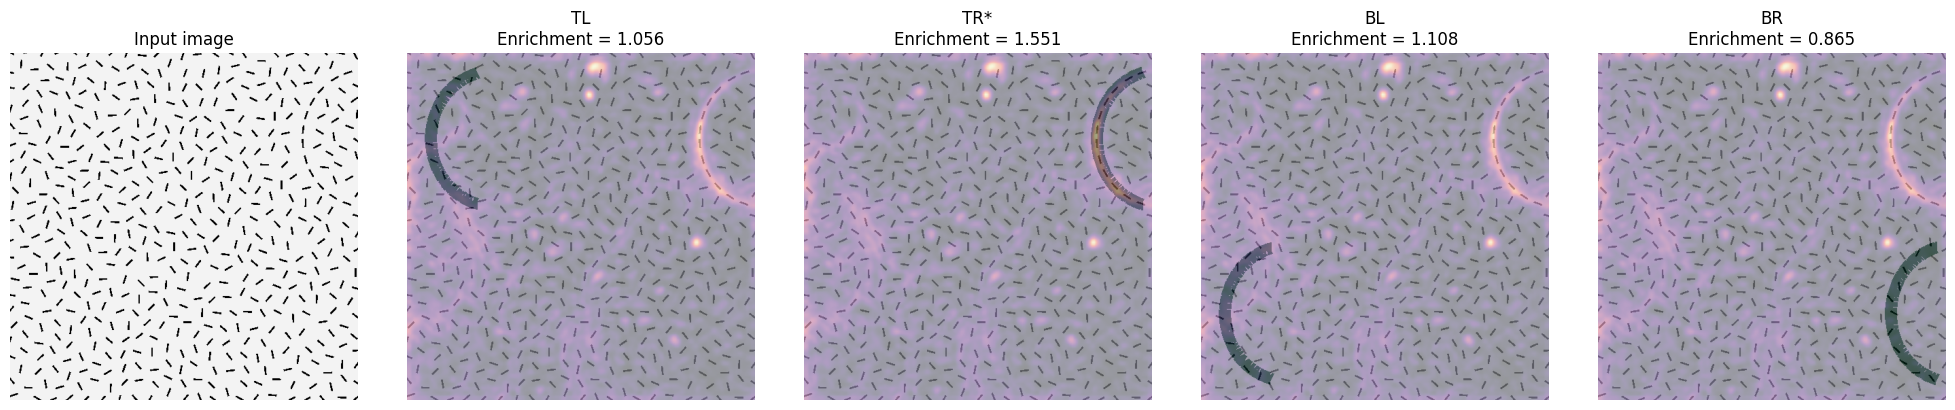

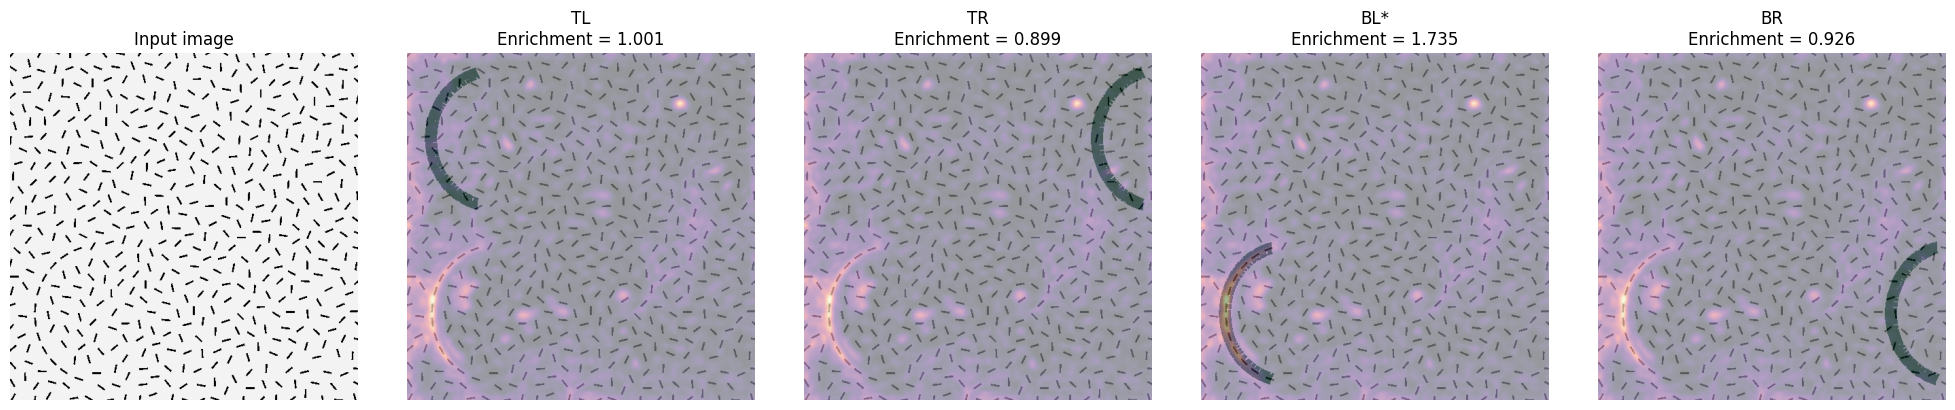

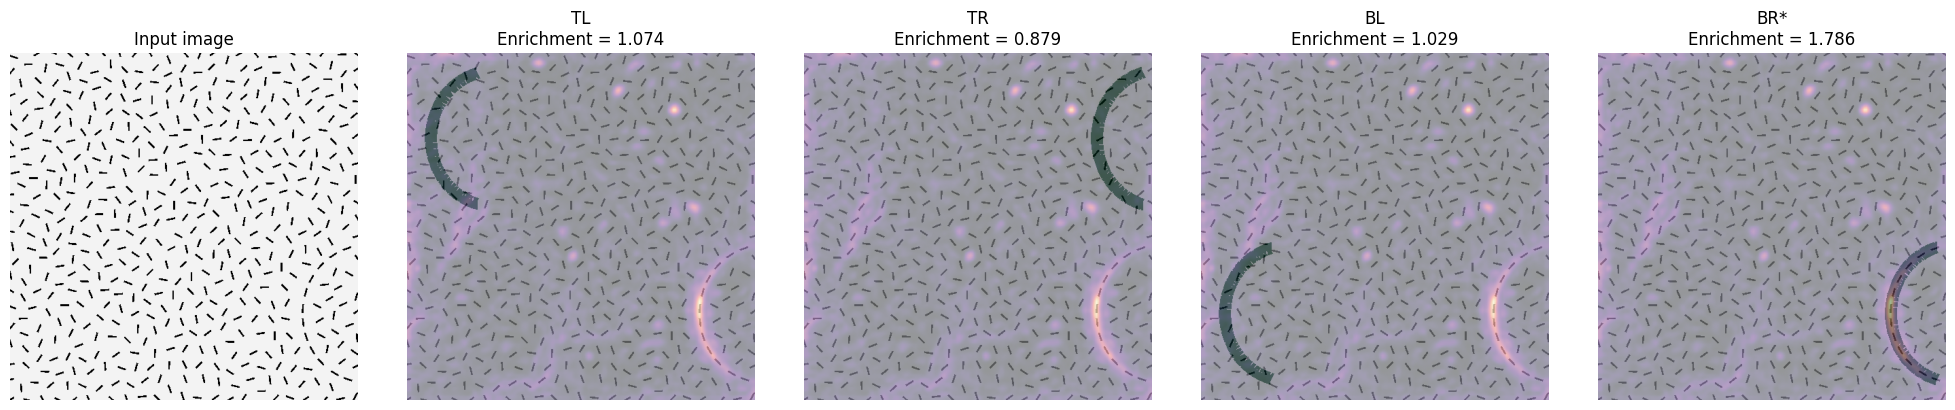

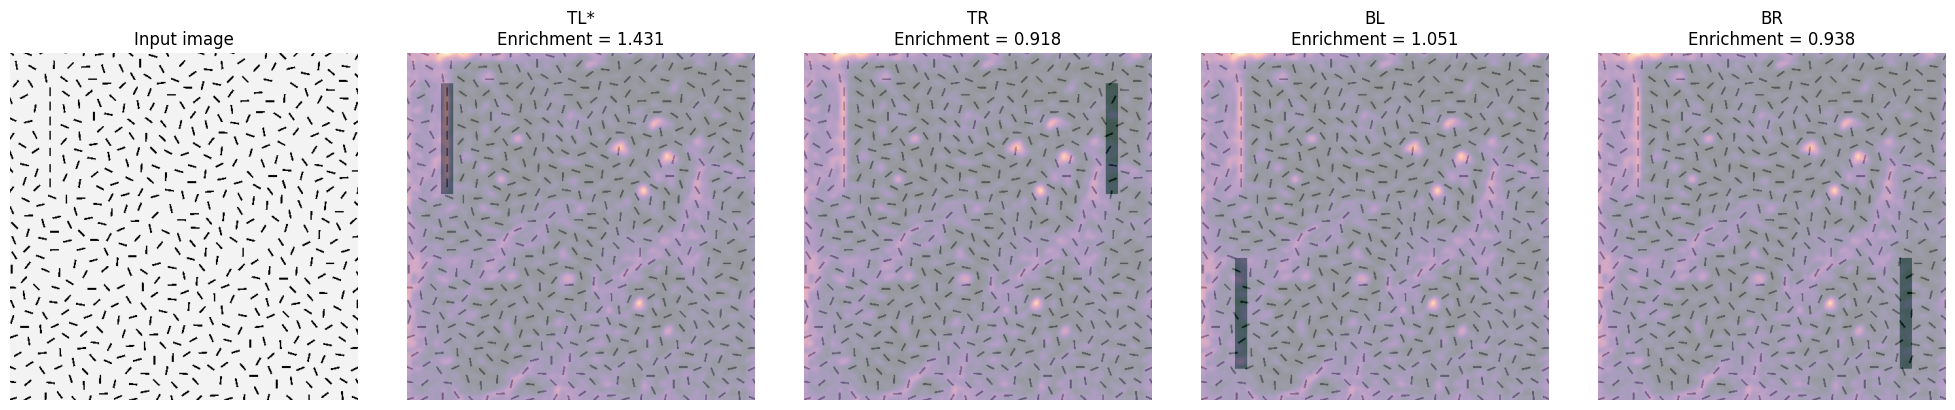

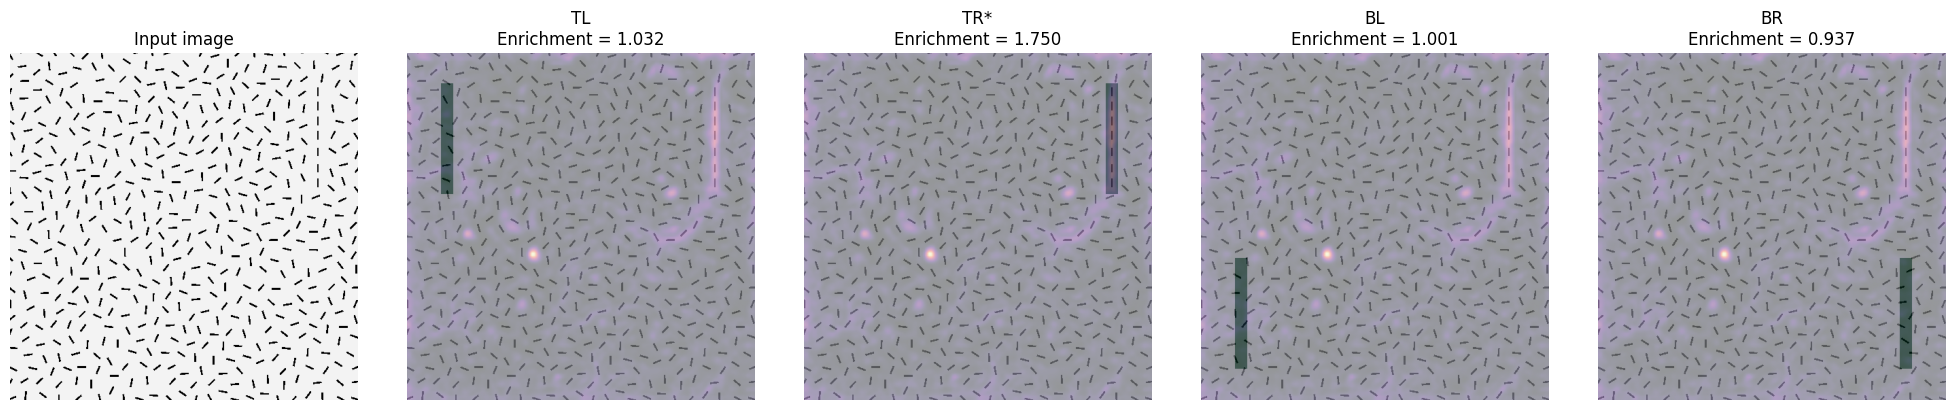

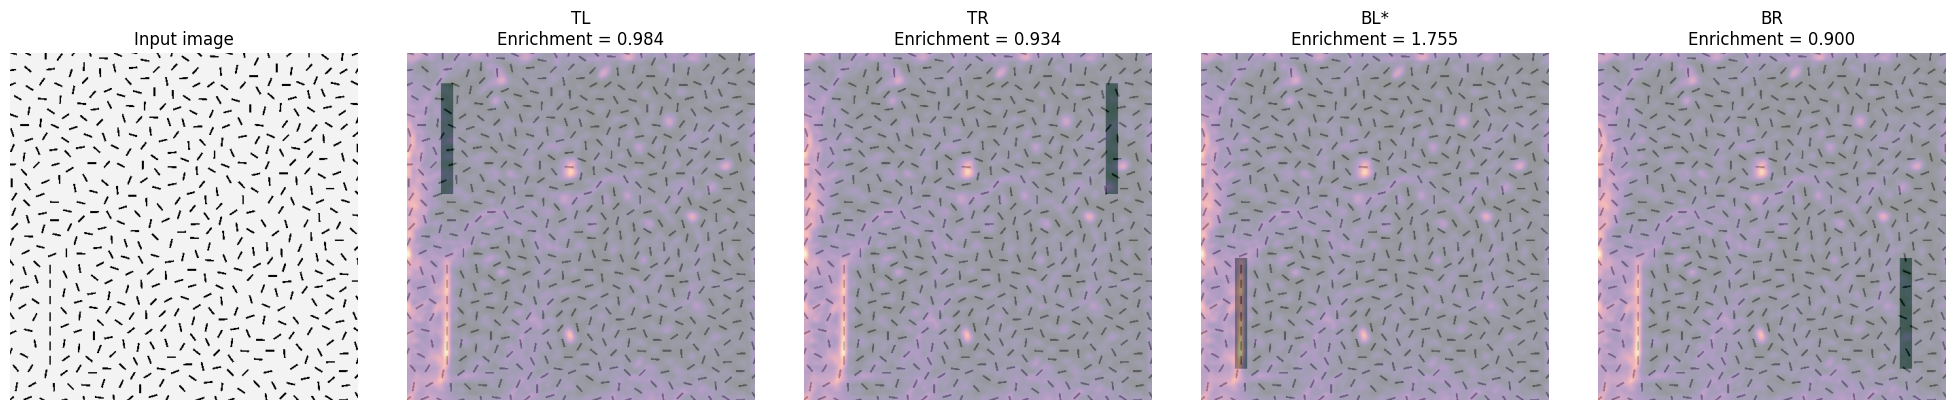

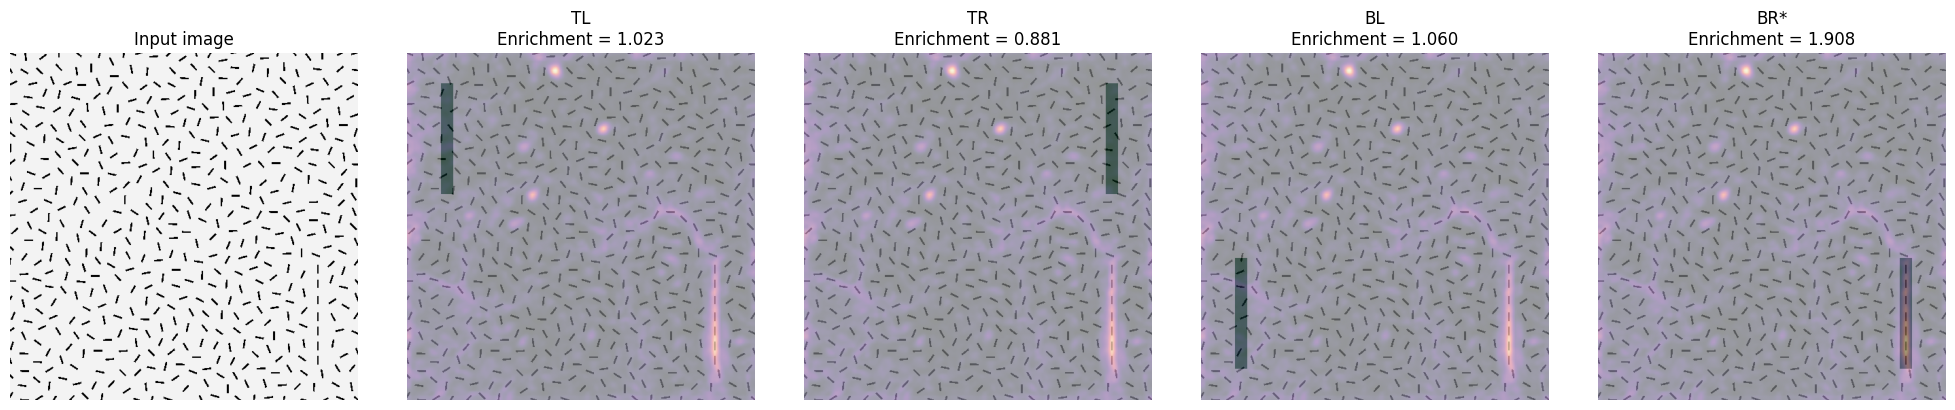

Saved baseline figures to: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/candidate_mask_visualizations/baseline


In [28]:
# ============================================================
# Visualisatie: C en straight, alle quadranten
# Input + heatmap met TL/TR/BL/BR kandidaatmaskers
# Gebruikt dezelfde activatiekaart als de enrichment-analyse
# ============================================================

from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

ALPHA_HEATMAP = 0.60
ALPHA_MASK = 0.35
QUADRANTS = ["TL", "TR", "BL", "BR"]


def normalize_for_plot_local(x):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.nanmin(x)
    vmax = np.nanmax(x)
    if vmax > 0:
        x = x / vmax
    return x


def resize_map_to_image_local(fmap, image_size):
    fmap_img = Image.fromarray(fmap.astype(np.float32), mode="F")
    fmap_img = fmap_img.resize(image_size, Image.BILINEAR)
    return np.array(fmap_img)


def get_true_quadrant_from_filename(path):
    fname = Path(path).name
    parts = fname.split("_")

    for q in QUADRANTS:
        if q in parts:
            return q

    return "unknown"


def activation_map_for_enrichment_visualization(row, use_bias=False):
    pil_img, img_tensor = load_image_tensor(row["path"])

    if use_bias:
        condition = matched_condition_for_contour(row["contour_type"])
        forward_condition(model, img_tensor, condition)
    else:
        reset_and_forward(model, img_tensor)

    state = get_state(model, ANALYSIS_LAYER).detach().cpu()

    # Zelfde activatiekaart als enrichment-analyse:
    # absolute activatie in ANALYSIS_LAYER, gemiddeld over alle channels
    fmap = state.abs().mean(dim=1).squeeze().numpy()

    fmap = resize_map_to_image_local(fmap, pil_img.size)

    return pil_img, fmap


def get_candidate_mask_paths(row):
    fname = Path(row["path"]).name
    mask_paths = []

    for target_q in QUADRANTS:
        candidate_name = fname

        for old_q in QUADRANTS:
            candidate_name = candidate_name.replace(f"_{old_q}_", f"_{target_q}_")

        mask_paths.append((target_q, MASK_DIR / candidate_name))

    return mask_paths


def compute_enrichment_for_mask(fmap, mask):
    mask = mask.astype(bool)

    inside = fmap[mask]
    outside = fmap[~mask]

    if inside.size == 0 or outside.size == 0:
        return np.nan

    outside_mean = outside.mean()
    if outside_mean == 0:
        return np.nan

    return inside.mean() / outside_mean


def plot_candidate_masks(row, use_bias=False, save_path=None):
    pil_img, fmap_raw = activation_map_for_enrichment_visualization(
        row,
        use_bias=use_bias,
    )

    fmap_plot = normalize_for_plot_local(fmap_raw)

    candidates = get_candidate_mask_paths(row)
    enrichments = []

    for quad, path in candidates:
        if not path.exists():
            raise FileNotFoundError(f"Masker niet gevonden: {path}")

        mask = np.array(Image.open(path).convert("L")) > 0
        mask = np.array(
            Image.fromarray(mask.astype(np.uint8)).resize(
                pil_img.size,
                Image.NEAREST,
            )
        ).astype(bool)

        enrichment = compute_enrichment_for_mask(fmap_raw, mask)
        enrichments.append((quad, path, mask, enrichment))

    best_quad = max(enrichments, key=lambda x: x[3])[0]
    true_quad = get_true_quadrant_from_filename(row["path"])

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(pil_img)
    axes[0].set_title("Input image")
    axes[0].axis("off")

    for ax, (quad, path, mask, enrichment) in zip(axes[1:], enrichments):
        ax.imshow(pil_img)
        ax.imshow(fmap_plot, cmap="magma", alpha=ALPHA_HEATMAP)
        ax.imshow(mask, cmap="Greens", alpha=ALPHA_MASK)

        marker = "*" if quad == best_quad else ""
        ax.set_title(f"{quad}{marker}\nEnrichment = {enrichment:.3f}")
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def select_example_row(contour_type, quadrant):
    subset = image_df[
        (image_df["contour_type"] == contour_type)
        & (image_df["path"].astype(str).str.contains(f"_{quadrant}_"))
    ]

    if len(subset) == 0:
        raise ValueError(f"Geen afbeelding gevonden voor {contour_type} {quadrant}")

    return subset.iloc[0]

# ============================================================
# Outputmap voor visualisaties
# ============================================================

VISUAL_DIR = OUTPUT_DIR / "candidate_mask_visualizations"
VISUAL_DIR.mkdir(exist_ok=True, parents=True)

BASELINE_VIS_DIR = VISUAL_DIR / "baseline"
BIAS_VIS_DIR = VISUAL_DIR / "matched_bias"

BASELINE_VIS_DIR.mkdir(exist_ok=True)
BIAS_VIS_DIR.mkdir(exist_ok=True)

# ============================================================
# Maak én sla baseline-plots op
# ============================================================

for contour_type in ["C", "straight"]:
    for quadrant in QUADRANTS:

        row = select_example_row(contour_type, quadrant)

        save_path = BASELINE_VIS_DIR / f"{contour_type}_{quadrant}.png"

        plot_candidate_masks(
            row,
            use_bias=False,
            save_path=save_path,
        )

print(f"Saved baseline figures to: {BASELINE_VIS_DIR}")

In [23]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'os', 're', 'sys', 'Path', 'np', 'pd', 'plt', 'Image', 'tqdm', 'torch', 'F', 'transforms', 'DEVICE', 'PROJECT_ROOT', 'CHECKPOINT_PATH', 'IMAGE_DIR', 'MASK_DIR', 'OUTPUT_DIR', 'CSV_DIR', 'PLOT_DIR', 'VIS_DIR', 'd', 'INPUT_SIZE', 'ANALYSIS_LAYER', 'CONTOURS', 'QUADRANTS', 'USE_ABS_ACTIVATION', 'SCORE_CHANNEL_MODE', 'BIAS_STRENGTH', 'BIAS_MODE', 'transform', '_i2', 'load_model', 'normalize_contour_label', 'parse_image_filename', 'candidate_mask_path', 'load_image_tensor', 'load_binary_mask', 'reset_and_forward', 'get_state', 'normalize_for_plot', '_i3', 'CLASSIFICATION_DIR', 'C_CHANNELS_CSV', 'STRAIGHT_CHANNELS_CSV', 'load_channel_list', 'C_CHANNELS', 'STRAIGHT_CHANNELS', '_i4', 'selected_channels_for_contour', 'channel_map', 'resize_map_to_image

In [26]:
# ============================================================
# Summary tables: yes/no performance per contour and quadrant
# met enrichment per kandidaatmasker
# ============================================================

summary_df = (
    results_df
    .groupby(["condition", "contour_type", "true_contour_quadrant"])
    .agg(
        n_images=("filename", "count"),
        n_match=("matches_true_quadrant", "sum"),
        proportion_match=("matches_true_quadrant", "mean"),

        enrichment_TL=("enrichment_TL", "mean"),
        enrichment_TR=("enrichment_TR", "mean"),
        enrichment_BL=("enrichment_BL", "mean"),
        enrichment_BR=("enrichment_BR", "mean"),

        mean_highest_enrichment=("highest_contour_enrichment", "mean"),
        mean_true_quadrant_enrichment=("true_quadrant_enrichment", "mean"),
    )
    .reset_index()
)

summary_path = CSV_DIR / "h1_quadrant_enrichment_summary_by_condition.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
display(summary_df)

Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/h1_quadrant_enrichment_summary_by_condition.csv


,condition,contour_type,true_contour_quadrant,n_images,n_match,proportion_match,enrichment_TL,enrichment_TR,enrichment_BL,enrichment_BR,mean_highest_enrichment,mean_true_quadrant_enrichment
0,baseline,C,BL,6,6,1.0,0.960496,0.895496,1.850323,0.915908,1.850323,1.850323
1,baseline,C,BR,6,6,1.0,1.042382,0.857586,1.073989,1.777635,1.777635,1.777635
2,baseline,C,TL,6,6,1.0,1.786312,0.891569,1.020014,0.913361,1.786312,1.786312
3,baseline,C,TR,6,6,1.0,1.011104,1.541632,1.124637,0.902982,1.541632,1.541632
4,baseline,straight,BL,6,6,1.0,1.025638,0.920787,1.817655,0.920266,1.817655,1.817655
5,baseline,straight,BR,6,6,1.0,0.975292,0.932210,1.056249,1.812149,1.812149,1.812149
6,baseline,straight,TL,6,6,1.0,1.609458,0.927657,1.039029,0.952495,1.609458,1.609458
7,baseline,straight,TR,6,6,1.0,1.015483,1.812424,0.979755,0.942502,1.812424,1.812424
8,matched_bias,C,BL,6,6,1.0,0.962020,0.913640,1.730959,0.925816,1.730959,1.730959
9,matched_bias,C,BR,6,6,1.0,1.034020,0.878686,1.054413,1.669530,1.669530,1.669530


In [27]:
# ============================================================
# Summary table: BASELINE ONLY
# ============================================================

summary_df = (
    baseline_df
    .groupby(["contour_type", "true_contour_quadrant"])
    .agg(
        n_images=("filename", "count"),
        n_match=("matches_true_quadrant", "sum"),
        proportion_match=("matches_true_quadrant", "mean"),

        enrichment_TL=("enrichment_TL", "mean"),
        enrichment_TR=("enrichment_TR", "mean"),
        enrichment_BL=("enrichment_BL", "mean"),
        enrichment_BR=("enrichment_BR", "mean"),

        mean_highest_enrichment=("highest_contour_enrichment", "mean"),
        mean_true_quadrant_enrichment=("true_quadrant_enrichment", "mean"),
    )
    .reset_index()
)

summary_path = CSV_DIR / "baseline_h1_quadrant_enrichment_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
display(summary_df)

Saved: /home/yentl/pytorch_gammanet/outputs_contour_mask_quadrant_baseline_vs_bias_025/csv/baseline_h1_quadrant_enrichment_summary.csv


,contour_type,true_contour_quadrant,n_images,n_match,proportion_match,enrichment_TL,enrichment_TR,enrichment_BL,enrichment_BR,mean_highest_enrichment,mean_true_quadrant_enrichment
0,C,BL,6,6,1.0,0.960496,0.895496,1.850323,0.915908,1.850323,1.850323
1,C,BR,6,6,1.0,1.042382,0.857586,1.073989,1.777635,1.777635,1.777635
2,C,TL,6,6,1.0,1.786312,0.891569,1.020014,0.913361,1.786312,1.786312
3,C,TR,6,6,1.0,1.011104,1.541632,1.124637,0.902982,1.541632,1.541632
4,straight,BL,6,6,1.0,1.025638,0.920787,1.817655,0.920266,1.817655,1.817655
5,straight,BR,6,6,1.0,0.975292,0.932210,1.056249,1.812149,1.812149,1.812149
6,straight,TL,6,6,1.0,1.609458,0.927657,1.039029,0.952495,1.609458,1.609458
7,straight,TR,6,6,1.0,1.015483,1.812424,0.979755,0.942502,1.812424,1.812424
